In [ ]:
# Mengimpor semua library yang diwajibkan [cite: 25]
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Menghilangkan warning agar output notebook rapi
import warnings
warnings.filterwarnings('ignore')

Kode ini merupakan tahap persiapan awal. Library numpy dan pandas digunakan untuk mengolah data tabel, sedangkan matplotlib dan seaborn untuk membuat visualisasi grafik. Modul dari sklearn diimpor untuk menjalankan proses inti Machine Learning, mulai dari prapemrosesan data, pelatihan model Linear Regression, hingga menghitung tingkat error. Terakhir, warnings digunakan untuk menyembunyikan pesan peringatan agar tampilan output tetap rapi

In [ ]:
from google.colab import files
import io

# Unggah file secara interaktif
print("Silakan unggah file CSV Anda:")
uploaded = files.upload()

df = None
if uploaded:
    # Asumsikan hanya satu file yang diunggah, ambil nama file pertama
    for fn in uploaded.keys():
        file_name = fn
        print(f'User uploaded file "{file_name}" with length {len(uploaded[file_name])} bytes')
        # Baca file CSV ke DataFrame
        df = pd.read_csv(io.BytesIO(uploaded[file_name]))
        break # Keluar setelah file pertama diproses
else:
    print("Tidak ada file yang diunggah. Mohon unggah file CSV untuk melanjutkan.")

# Menampilkan 5 data teratas jika df berhasil dibuat
if df is not None:
    display(df.head())
    print(f"Jumlah baris dan kolom: {df.shape}")

Silakan unggah file CSV Anda:


Saving Test.csv to Test (1).csv
Saving Train.csv to Train.csv
User uploaded file "Test (1).csv" with length 527709 bytes


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1
1,FDW14,8.300,reg,0.038428,Dairy,87.3198,OUT017,2007,NaN,Tier 2,Supermarket Type1
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998,NaN,Tier 3,Grocery Store
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,NaN,Tier 2,Supermarket Type1
4,FDY38,NaN,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3


Jumlah baris dan kolom: (5681, 11)


Memunculkan tombol interaktif agar bisa mengunggah file CSV secara manual dari komputer ke ruang kerja cloud Colab. Setelah file terunggah (files.upload()), sistem akan membacanya sebagai aliran byte (io.BytesIO) dan mengonversinya menjadi tabel Pandas DataFrame (pd.read_csv). Jika proses pembacaan berhasil, program akan otomatis menampilkan 5 baris pertama beserta informasi total baris dan kolom dataset tersebut.

In [ ]:
# Memuat ulang df dengan Train.csv karena Test.csv tidak memiliki Item_Outlet_Sales
# Asumsi Train.csv sudah diunggah ke lingkungan Colab

if 'Train.csv' in uploaded:
    df = pd.read_csv(io.BytesIO(uploaded['Train.csv']))
    print("Berhasil memuat 'Train.csv'.")
    display(df.head())
    print(f"Jumlah baris dan kolom setelah memuat Train.csv: {df.shape}")
else:
    print("File 'Train.csv' tidak ditemukan di antara file yang diunggah.")
    print("Mohon pastikan Anda mengunggah 'Train.csv' jika ingin menganalisis 'Item_Outlet_Sales'.")

# Periksa lagi apakah 'Item_Outlet_Sales' ada setelah pemuatan
if 'Item_Outlet_Sales' not in df.columns:
    print("Peringatan: 'Item_Outlet_Sales' masih belum ada di DataFrame.")

Berhasil memuat 'Train.csv'.


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


Jumlah baris dan kolom setelah memuat Train.csv: (8523, 12)


Kode ini berfungsi untuk mencari dan memuat khusus file bernama 'Train.csv' dari memori Google Colab, lalu menampilkannya. Setelah itu, sistem melakukan pengecekan ganda untuk memastikan bahwa kolom target prediksi kita, yaitu Item_Outlet_Sales, benar-benar ada di dalam tabel tersebut.

In [ ]:
print("Informasi Tipe Data dan Jumlah Non-Null:")
df.info()

Informasi Tipe Data dan Jumlah Non-Null:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5681 entries, 0 to 5680
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            5681 non-null   object 
 1   Item_Weight                4705 non-null   float64
 2   Item_Fat_Content           5681 non-null   object 
 3   Item_Visibility            5681 non-null   float64
 4   Item_Type                  5681 non-null   object 
 5   Item_MRP                   5681 non-null   float64
 6   Outlet_Identifier          5681 non-null   object 
 7   Outlet_Establishment_Year  5681 non-null   int64  
 8   Outlet_Size                4075 non-null   object 
 9   Outlet_Location_Type       5681 non-null   object 
 10  Outlet_Type                5681 non-null   object 
dtypes: float64(3), int64(1), object(7)
memory usage: 488.3+ KB


Kode ini berfungsi untuk menampilkan ringkasan cepat dari struktur tabel dataset. Perintah df.info() akan secara otomatis mencetak daftar nama kolom, tipe data di setiap kolom (apakah berupa teks/objek atau angka), serta jumlah baris data yang terisi penuh (non-null). Informasi ini sangat krusial pada tahap awal eksplorasi untuk langsung mengetahui kolom mana saja yang memiliki data kosong atau hilang (missing values) sehingga kita bisa membersihkannya di tahap selanjutnya.

In [ ]:
print("\nPersentase Missing Values:")
missing_values_percentage = df.isnull().sum() / len(df) * 100
display(missing_values_percentage[missing_values_percentage > 0].sort_values(ascending=False))


Persentase Missing Values:


,0
Outlet_Size,28.269671
Item_Weight,17.180074


Kode ini berfungsi untuk menghitung dan menampilkan persentase data yang kosong (missing values) pada setiap kolom. Kode tersebut menghitung rasionya, menyaring agar hanya memunculkan kolom yang benar-benar bermasalah (persentase > 0), lalu mengurutkannya dari persentase kerusakan yang paling parah hingga yang paling ringan (ascending=False).

Statistik Deskriptif:


,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


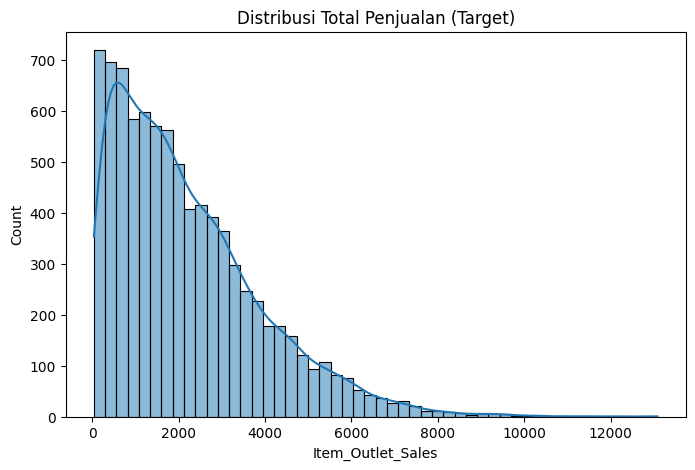

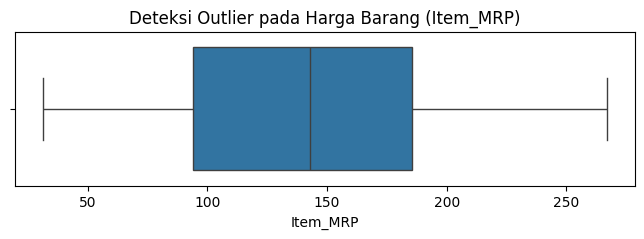

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Statistik Deskriptif
print("Statistik Deskriptif:")
display(df.describe())

# 2. Distribusi Data Target (Item_Outlet_Sales)
if 'Item_Outlet_Sales' in df.columns:
    plt.figure(figsize=(8, 5))
    sns.histplot(df['Item_Outlet_Sales'], bins=50, kde=True)
    plt.title('Distribusi Total Penjualan (Target)')
    plt.show()
else:
    print("\nPERINGATAN: Kolom 'Item_Outlet_Sales' tidak ditemukan. Pastikan Anda memuat 'Train.csv', bukan 'Test.csv'.")

# 3. Deteksi Outlier pada Harga Barang (Item_MRP)
if 'Item_MRP' in df.columns:
    plt.figure(figsize=(8, 2))
    sns.boxplot(x=df['Item_MRP'])
    plt.title('Deteksi Outlier pada Harga Barang (Item_MRP)')
    plt.show()
else:
    print("Kolom 'Item_MRP' tidak ditemukan.")

Pertama, df.describe() akan menampilkan tabel ringkasan matematis (seperti nilai rata-rata, nilai tengah/median, angka tertinggi, dan terendah) untuk semua kolom angka. Kedua, kode memunculkan grafik Histogram dari Item_Outlet_Sales untuk melihat pola sebaran angka penjualan (apakah kebanyakan toko berpendapatan rendah atau tinggi). Terakhir, kode memunculkan grafik Boxplot dari Item_MRP (Harga Barang) untuk mendeteksi apakah ada harga barang yang outlier (sangat tidak wajar atau melenceng jauh dari harga rata-rata). Kode ini juga dilengkapi sistem pengaman (if-else) yang akan memberi peringatan jika kolom yang dicari ternyata tidak ada di dalam file CSV

In [ ]:
# Cek missing values
print("Missing values sebelum preprocessing:\n", df.isnull().sum())

# Handling Missing Values
# Kolom 'Item_Weight' diisi dengan nilai rata-rata (mean)
df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Weight'].mean())

# Kolom 'Outlet_Size' diisi dengan modus (nilai yang paling sering muncul)
df['Outlet_Size'] = df['Outlet_Size'].fillna(df['Outlet_Size'].mode()[0])

# Encoding Variabel Kategorikal menggunakan LabelEncoder
le = LabelEncoder()
kategori_kolom = df.select_dtypes(include=['object']).columns

for col in kategori_kolom:
    df[col] = le.fit_transform(df[col])

print("\nMissing values setelah preprocessing:\n", df.isnull().sum())

Missing values sebelum preprocessing:
 Item_Identifier                 0
Item_Weight                  1463
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  2410
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales               0
dtype: int64

Missing values setelah preprocessing:
 Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64


Pertama, program mengecek jumlah data yang kosong (missing values) di setiap kolom. Jika ada data kosong pada kolom angka Item_Weight (Berat Barang), kekosongan itu diisi menggunakan nilai rata-rata (mean) dari seluruh barang. Jika yang kosong adalah kolom teks Outlet_Size (Ukuran Toko), maka diisi menggunakan nilai modus (ukuran toko yang paling sering muncul di data). Setelah data tidak ada yang bolong, program menggunakan fungsi LabelEncoder untuk mengubah semua kolom yang berisi teks (object) menjadi angka (misalnya: "Kecil", "Sedang", "Besar" menjadi 0, 1, 2) karena mesin Linear Regression hanya bisa berhitung menggunakan angka. Terakhir, program kembali memastikan bahwa tidak ada lagi data yang berstatus missing value.

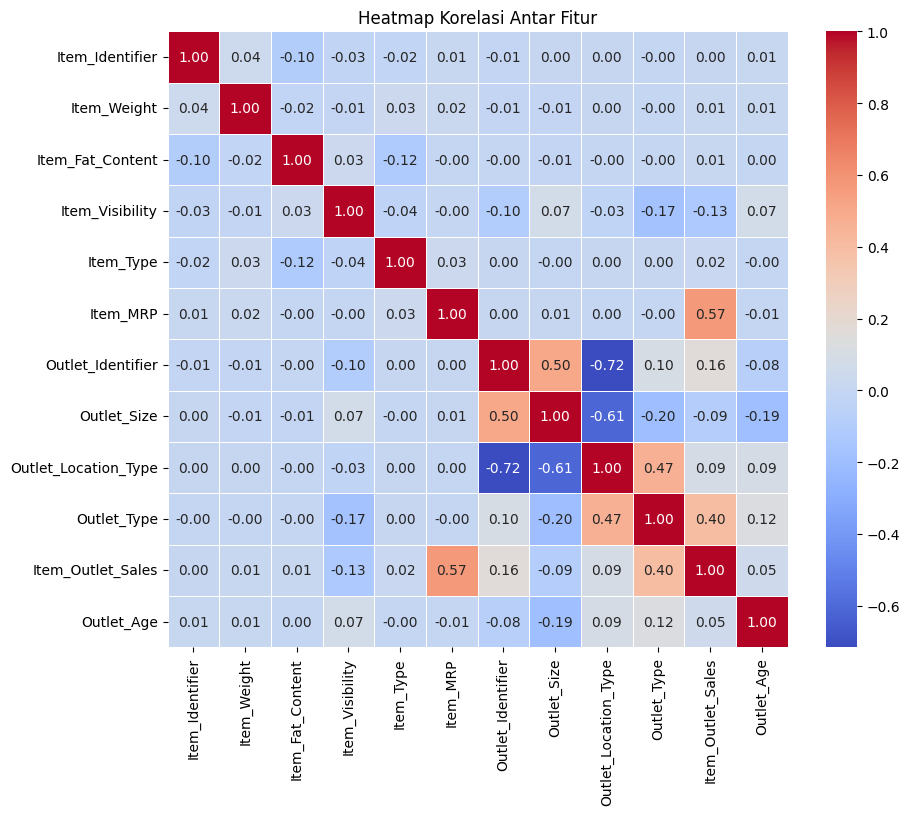

In [ ]:
# Feature Engineering: Membuat fitur umur toko (Asumsi tahun saat ini 2026)
df['Outlet_Age'] = 2026 - df['Outlet_Establishment_Year']

# Menghapus kolom tahun pendirian karena sudah digantikan oleh umur toko
df = df.drop(['Outlet_Establishment_Year'], axis=1)

# Visualisasi Wajib 1: Heatmap Korelasi [cite: 34]
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur')
plt.show()

Kode ini menjalankan dua langkah analitis yang sangat penting: Feature Engineering dan Visualisasi Korelasi. Pertama, program menciptakan logika baru dengan membuat kolom Outlet_Age (Umur Toko) hasil pengurangan tahun 2026 dengan tahun pendirian toko, lalu membuang kolom tahun pendirian aslinya agar mesin tidak kebingungan membaca data yang bermakna sama. Setelah itu, kode memunculkan Heatmap Korelasi, yakni sebuah grafik matriks warna-warni yang secara otomatis menghitung dan menampilkan seberapa kuat hubungan tarik-menarik antar semua kolom datamu (misalnya, untuk melihat apakah harga barang memiliki hubungan yang sangat erat dengan tingginya total penjualan).

In [ ]:
# Target prediksi
y = df['Item_Outlet_Sales']

# Fitur untuk Multiple Linear Regression (semua fitur kecuali target dan ID)
X_multi = df.drop(['Item_Outlet_Sales', 'Item_Identifier', 'Outlet_Identifier'], axis=1)

# Fitur untuk Simple Linear Regression (hanya menggunakan fitur dengan korelasi tertinggi: Item_MRP)
X_simple = df[['Item_MRP']]

# Feature Scaling
scaler = StandardScaler()
X_multi_scaled = scaler.fit_transform(X_multi)
X_simple_scaled = scaler.fit_transform(X_simple)

Kode ini menjalankan tahap Pemisahan Variabel dan Penyesuaian Skala Data (Feature Scaling) untuk memenuhi syarat pemodelan.

Pertama, program memisahkan tabel menjadi target yang ingin ditebak (y, yaitu total penjualan) dan data prediktor/petunjuk (X). Untuk model Multiple Linear Regression, kita menggunakan hampir semua kolom yang relevan sebagai petunjuk (X_multi), sedangkan untuk Simple Linear Regression, kita hanya memakai satu petunjuk utama yaitu harga barang (X_simple).

Langkah terakhir menggunakan StandardScaler sangat krusial untuk menyamakan skala angka di semua kolom fitur. Tanpa standarisasi ini, algoritma bisa "bingung" karena rentang angka harga barang (ribuan) jauh lebih besar daripada umur toko (puluhan). Hal itu bisa membuat mesin salah mengira bahwa variabel dengan digit yang lebih banyak otomatis memiliki bobot yang lebih penting.

In [ ]:
# Split data Multiple LR
X_train_m, X_test_m, y_train, y_test = train_test_split(X_multi_scaled, y, test_size=0.2, random_state=42)

# Split data Simple LR (y_train dan y_test sama)
X_train_s, X_test_s, _, _ = train_test_split(X_simple_scaled, y, test_size=0.2, random_state=42)

print(f"Jumlah data training: {X_train_m.shape[0]}")
print(f"Jumlah data testing: {X_test_m.shape[0]}")

Jumlah data training: 6818
Jumlah data testing: 1705


Fungsi train_test_split memotong keseluruhan data menjadi dua bagian utama: 80% digunakan sebagai bahan ajar atau data latih (train) agar algoritma bisa mengenali pola penjualan, sedangkan 20% sisanya (test_size=0.2) disembunyikan sebagai soal ujian (test) untuk mengetes seberapa akurat tebakan model nanti. Penggunaan random_state=42 berfungsi sebagai pengunci agar hasil acakan pemotongan data ini selalu sama dan tidak berubah-ubah (reproducible) setiap kali Jupyter Notebook dijalankan ulang. Tanda garis bawah (_) pada pemisahan kedua digunakan sekadar untuk membuang/mengabaikan hasil pembagian target y yang terduplikasi.

In [ ]:
model_simple = LinearRegression()
model_simple.fit(X_train_s, y_train)

# Melakukan prediksi
y_pred_simple = model_simple.predict(X_test_s)

Kode ini adalah momen di mana mesin benar-benar mulai belajar dan diuji.

Perintah LinearRegression() bertugas menyiapkan algoritma kecerdasan buatan dasar yang masih "kosong". Lalu, fungsi .fit() bertindak sebagai proses pembelajaran utama; di sinilah model membaca data latih untuk secara matematis memahami pola hubungan antara harga barang (X_train_s) dan hasil penjualannya (y_train). Setelah model tersebut pintar dan menemukan polanya, fungsi .predict() menyuruh model tersebut untuk mencoba menebak angka penjualan dari kumpulan data ujian yang disembunyikan sebelumnya (X_test_s). Hasil tebakan inilah (y_pred_simple) yang nantinya dijadikan bahan evaluasi untuk menilai seberapa akurat model tersebut.

In [ ]:
model_multi = LinearRegression()
model_multi.fit(X_train_m, y_train)

# Melakukan prediksi
y_pred_multi = model_multi.predict(X_test_m)

Kode ini memiliki alur kerja yang sama persis dengan langkah sebelumnya, namun kali ini ditujukan untuk membangun model Multiple Linear Regression.

Perbedaan utamanya terletak pada data yang disuapkan ke dalam fungsi .fit(); alih-alih hanya mengandalkan satu fitur, dengan memasukkan X_train_m yang berisi kombinasi banyak petunjuk sekaligus (seperti harga barang, umur toko, tipe barang, dan ukuran toko). Mesin kini diajarkan untuk memahami bagaimana seluruh faktor tersebut secara bersama-sama memengaruhi total penjualan (y_train). Setelah mesin berhasil memetakan pola yang lebih kompleks tersebut, perintah .predict() kembali digunakan untuk menguji kemampuannya menebak angka penjualan pada sekumpulan data ujian (X_test_m).

In [ ]:
def evaluasi_model(y_asli, y_prediksi, nama_model):
    mae = mean_absolute_error(y_asli, y_prediksi)
    mse = mean_squared_error(y_asli, y_prediksi)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_asli, y_prediksi)

    print(f"--- Evaluasi {nama_model} ---")
    print(f"MAE  : {mae:.2f}")
    print(f"RMSE : {rmse:.2f}")
    print(f"R2   : {r2:.4f}\n")

evaluasi_model(y_test, y_pred_simple, "Simple Linear Regression (1 Fitur)")
evaluasi_model(y_test, y_pred_multi, "Multiple Linear Regression (Banyak Fitur)")

--- Evaluasi Simple Linear Regression (1 Fitur) ---
MAE  : 991.47
RMSE : 1348.41
R2   : 0.3310

--- Evaluasi Multiple Linear Regression (Banyak Fitur) ---
MAE  : 856.41
RMSE : 1137.14
R2   : 0.5242



Kode ini berfungsi sebagai tahap Evaluasi Model untuk mengukur seberapa akurat tebakan algoritma yang sudah dilatih.

Pertama, program mendefinisikan sebuah fungsi otomatis bernama evaluasi_model yang akan menghitung metrik atau "rapor" dari mesin, yaitu: MAE (rata-rata selisih kesalahan antara tebakan dan nilai asli), RMSE (mirip dengan MAE, tapi memberi bobot penalti lebih besar jika ada tebakan yang melesetnya terlalu jauh), dan R-squared (persentase kecocokan model dalam menjelaskan pola data).

Di dua baris terakhir, fungsi ini dieksekusi dua kali untuk menghitung dan membandingkan langsung skor antara model Simple Linear Regression (1 fitur) dengan Multiple Linear Regression (banyak fitur).

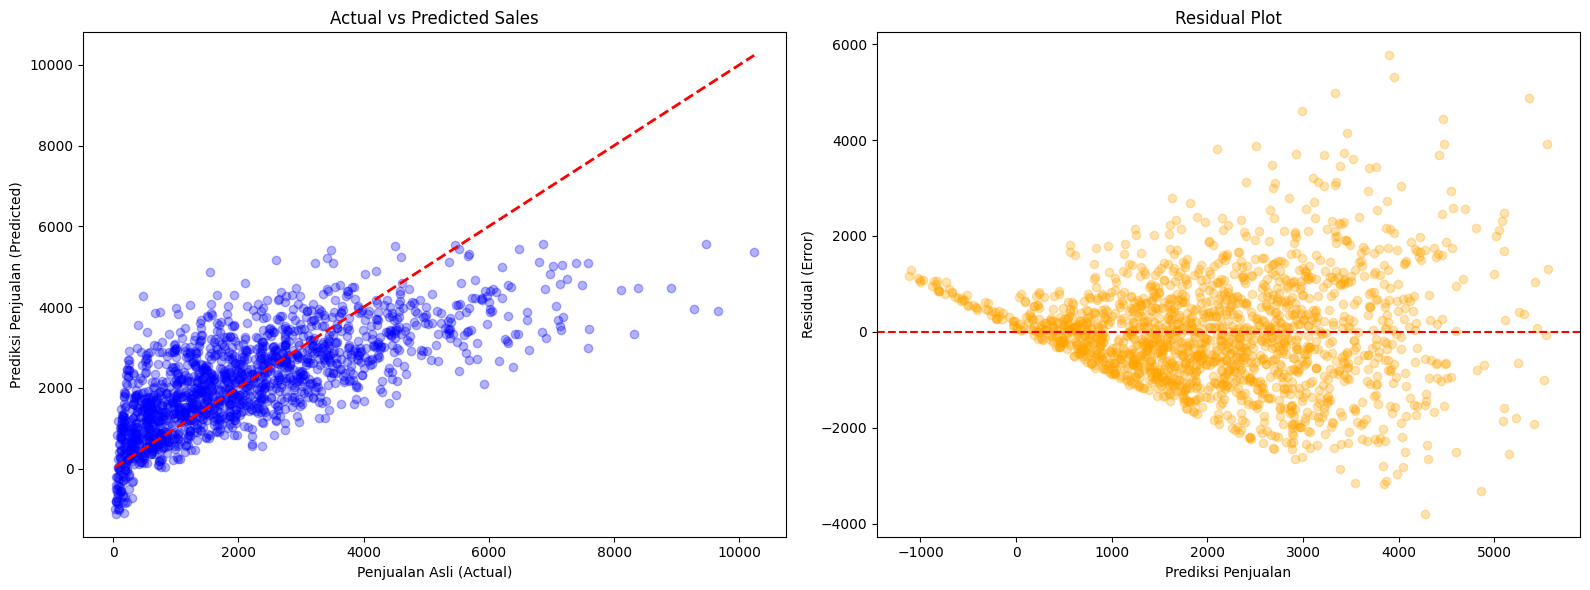

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Visualisasi Wajib 2: Scatter Plot (Actual vs Predicted) [cite: 34]
axes[0].scatter(y_test, y_pred_multi, alpha=0.3, color='blue')
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2)
axes[0].set_xlabel('Penjualan Asli (Actual)')
axes[0].set_ylabel('Prediksi Penjualan (Predicted)')
axes[0].set_title('Actual vs Predicted Sales')

# Visualisasi Wajib 3: Residual Plot [cite: 34]
residuals = y_test - y_pred_multi
axes[1].scatter(y_pred_multi, residuals, alpha=0.3, color='orange')
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Prediksi Penjualan')
axes[1].set_ylabel('Residual (Error)')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

Kode ini berfungsi untuk merender dua grafik evaluasi visual secara bersebelahan, yang bertujuan untuk membedah performa dan letak kelemahan model secara lebih mendalam.

Berikut adalah penjelasan singkat yang bisa kamu masukkan ke laporan:

Bagian pertama (axes[0]) membuat grafik Scatter Plot yang membandingkan nilai penjualan asli (y_test) dengan hasil tebakan mesin (y_pred_multi). Garis diagonal merah putus-putus bertindak sebagai batas ideal komparasi; jika sebuah titik biru berada tepat di atas garis tersebut, artinya tebakan model 100% akurat sesuai kenyataan.

Bagian kedua (axes[1]) menciptakan grafik Residual Plot. Program terlebih dahulu menghitung nilai error (selisih antara nilai asli dan tebakan), lalu memetakannya sebagai sebaran titik oranye. Garis horizontal merah di angka 0 merepresentasikan kondisi sempurna tanpa error. Semakin titik oranye menyebar menjauhi garis merah ini, berarti semakin besar pula tingkat kemelesetan tebakan model pada rentang penjualan tersebut. Diakhiri dengan plt.tight_layout() untuk memastikan tata letak margin kedua grafik rapi dan tidak saling tumpang tindih saat ditampilkan.